# Brian2 Simulation from SONATA

Demonstrates the two obi-one steps, mirrored from the NEST branch's `nest_simulation_from_sonata.ipynb`:

1. Generate a SONATA simulation campaign targeted at Brian2 using `Brian2CircuitSimulationScanConfig`. Each scan coordinate produces a `simulation_config.json` with `target_simulator: "BRIAN2"`. The Poisson drive of the sugar neurons is expressed as a `Brian2DirectPoissonStimulus` block.
2. Execute each generated `simulation_config.json` with `Brian2SimulationFromSonataTask`, which loads the SONATA circuit, builds the Brian2 `NeuronGroup`/`Synapses`, applies stimuli/reports through the mirrored `brian2_blocks` handlers, and writes SONATA-compatible `spikes.h5`.

Prerequisites: run `drosophila_to_brian2_sonata.ipynb` once so the SONATA circuit exists at `./sonata_circuit/`.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('brian2') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'brian2'])

In [2]:
import json
import logging
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

HERE = Path.cwd()
CIRCUIT_DIR = HERE / 'sonata_circuit'
CIRCUIT_CFG_PATH = CIRCUIT_DIR / 'circuit_config.json'
OUTPUT_ROOT = HERE / 'obi_simulation_output'
OUTPUT_ROOT.mkdir(exist_ok=True)

assert CIRCUIT_CFG_PATH.exists(), (
    f'{CIRCUIT_CFG_PATH} not found. Run drosophila_to_brian2_sonata.ipynb first.'
)
print(f'Circuit config: {CIRCUIT_CFG_PATH}')
print(f'Output root:    {OUTPUT_ROOT}')

Circuit config: /Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/sonata_circuit/circuit_config.json
Output root:    /Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/obi_simulation_output


## 1. Generate the SONATA simulation campaign

Build a `Brian2CircuitSimulationScanConfig`, sweep over a couple of random seeds, and execute `GenerateSimulationTask` via `CoupledScanGenerationTask` to produce one `simulation_config.json` per coordinate.

The Poisson drive of the sugar neurons is specified declaratively as a `Brian2DirectPoissonStimulus` block in the scan config, so the generated SONATA config already contains the `inputs` entry — no post-hoc patching needed.

In [3]:
from obi_one.core.info import Info
from obi_one.core.run_tasks import run_task_for_single_configs
from obi_one.core.scan_generation import CoupledScanGenerationTask
from obi_one.core.tuple import NamedTuple
from obi_one.scientific.blocks.neuron_sets.id import IDNeuronSet
from obi_one.scientific.blocks.neuron_sets.specific import AllNeurons
from obi_one.scientific.blocks.stimuli.brian2_poisson import Brian2DirectPoissonStimulus
from obi_one.scientific.library.circuit import Circuit
from obi_one.scientific.tasks.generate_simulations.config.brian2_circuit import (
    Brian2CircuitSimulationScanConfig,
)

In [4]:
SIM_LENGTH_MS = 200.0
SIM_DT_MS = 0.1
SEEDS = [42, 43]
POISSON_RATE_HZ = 150.0
POISSON_WEIGHT_V = 0.275e-3 * 250.0  # w_syn * f_poi from the reference model (~68.75 mV)
V_INIT_MV = -52.0  # matches the reference model's resting/reset potential (v_0 = v_rst)

# Load the sugar-neuron indices that the conversion notebook stored in the
# circuit's node_sets.json and register them as a fresh IDNeuronSet so the
# scan config can reference them without colliding with the existing entry.
with (CIRCUIT_DIR / 'node_sets.json').open() as f:
    sugar_indices = json.load(f)['sugar_neurons']['node_id']

circuit = Circuit(name='fly', path=str(CIRCUIT_CFG_PATH.absolute()))
pop_name = 'fly'
print(f'Circuit loaded: {pop_name} ({circuit.sonata_circuit.nodes[pop_name].size} neurons)')

sim_conf = Brian2CircuitSimulationScanConfig.empty_config()

info = Info(
    campaign_name='Brian2 fly demo',
    campaign_description=f'{SIM_LENGTH_MS:.0f} ms Brian2 simulation of the fly brain',
)
sim_conf.set(info, name='info')

all_neurons = AllNeurons()
sim_conf.add(all_neurons, name='AllNeurons')

sugar_drive_set = IDNeuronSet(
    neuron_ids=NamedTuple(name='sugar', elements=tuple(int(i) for i in sugar_indices)),
)
sim_conf.add(sugar_drive_set, name='SugarDrive')

poisson_drive = Brian2DirectPoissonStimulus(
    neuron_set=sugar_drive_set.ref,
    frequency=POISSON_RATE_HZ,
    weight=POISSON_WEIGHT_V,
    target_var='v',
    zero_refractory=True,
    duration=SIM_LENGTH_MS,
)
sim_conf.add(poisson_drive, name='poisson_sugar')

initialize = Brian2CircuitSimulationScanConfig.Initialize(
    circuit=circuit,
    simulation_length=SIM_LENGTH_MS,
    random_seed=SEEDS,
    v_init=V_INIT_MV,
)
# Match Brian2's default integration timestep (the reference run_trial uses
# defaultclock.dt = 0.1 ms) so the two flows consume the RNG stream the same
# way. _timestep is a private attr on the base config.
initialize._timestep = SIM_DT_MS
sim_conf.set(initialize, name='initialize')

validated = sim_conf.validated_config()
print(validated)

Circuit loaded: fly (127400 neurons)
Brian2CircuitSimulationScanConfig(type='Brian2CircuitSimulationScanConfig', info=Info(type='Info', campaign_name='Brian2 fly demo', campaign_description='200 ms Brian2 simulation of the fly brain'), timestamps={}, recordings={}, neuron_sets={'AllNeurons': AllNeurons(type='AllNeurons', sample_percentage=100.0, sample_seed=1), 'SugarDrive': IDNeuronSet(type='IDNeuronSet', sample_percentage=100.0, sample_seed=1, neuron_ids=sugar)}, initialize=Initialize(type='Brian2CircuitSimulationScanConfig.Initialize', circuit=Circuit(name='fly', path='/Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/sonata_circuit/circuit_config.json', matrix_path=None, type='Circuit'), simulation_length=200.0, extracellular_calcium_concentration=1.1, v_init=-52.0, random_seed=[42, 43], node_set=None), stimuli={'poisson_sugar': Brian2DirectPoissonStimulus(type='Brian2DirectPoissonStimulus', neuron_set=NeuronSetReference(block_dict_name='neuron_se

In [5]:
campaign_dir = str(OUTPUT_ROOT / 'campaign')
coupled_scan = CoupledScanGenerationTask(form=validated, output_root=campaign_dir)
coupled_scan.multiple_value_parameters(display=True)
coupled_scan.execute()

# _timestep is a PrivateAttr on Initialize, so it's dropped when the scan machinery
# re-creates the config via model_dump/model_validate. Re-assert SIM_DT_MS on each
# generated single config before GenerateSimulationTask reads it into run.dt.
for sc in coupled_scan.single_configs:
    sc.initialize._timestep = SIM_DT_MS

run_task_for_single_configs(single_configs=coupled_scan.single_configs)

single_configs = coupled_scan.single_configs
coord_roots = [Path(sc.coordinate_output_root) for sc in single_configs]
print(f'\nGenerated {len(single_configs)} simulation coordinate(s)')
for cr in coord_roots:
    print(f'  {cr}')

[2026-04-15 23:26:21,613] INFO: 
MULTIPLE VALUE PARAMETERS
[2026-04-15 23:26:21,613] INFO: initialize.random_seed: [42, 43]
[2026-04-15 23:26:21,616] INFO: initialize.circuit is a Circuit instance.
[2026-04-15 23:26:21,617] INFO: initialize.node_set is None — setting default node set.
[2026-04-15 23:26:21,790] INFO: initialize.circuit is a Circuit instance.
[2026-04-15 23:26:21,790] INFO: initialize.node_set is None — setting default node set.

Generated 2 simulation coordinate(s)
  /Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/obi_simulation_output/campaign/initialize.random_seed=42
  /Users/james/Documents/obi/code/obi-main/obi-one/examples/J_drosophila_brian2_sonata/obi_simulation_output/campaign/initialize.random_seed=43


In [6]:
sim_config_path = coord_roots[0] / 'simulation_config.json'
with sim_config_path.open() as f:
    generated = json.load(f)

print(f'target_simulator: {generated["target_simulator"]}')
print(f'tstop:            {generated["run"]["tstop"]} ms')
print(f'random_seed:      {generated["run"]["random_seed"]}')
print(f'inputs:           {list(generated.get("inputs", {}).keys())}')
print(f'reports:          {list(generated.get("reports", {}).keys())}')

target_simulator: BRIAN2
tstop:            200.0 ms
random_seed:      42
inputs:           ['poisson_sugar']
reports:          []


## 2. Run the Brian2 simulation

Feed each generated `simulation_config.json` through `Brian2SimulationFromSonataTask`.

In [7]:
logging.basicConfig(level=logging.INFO, format='%(levelname)s %(name)s: %(message)s')

In [8]:
from obi_one.core.path import NamedPath
from obi_one.scientific.tasks.brian2_simulation_from_sonata.config import (
    Brian2SimulationFromSonataSingleConfig,
)
from obi_one.scientific.tasks.brian2_simulation_from_sonata.task import (
    Brian2SimulationFromSonataTask,
)

for i, coord_root in enumerate(coord_roots):
    sc_sim_config = coord_root / 'simulation_config.json'
    print(f'\n--- Coordinate {i + 1}/{len(coord_roots)}: {coord_root.name} ---')

    brian2_run_config = Brian2SimulationFromSonataSingleConfig(
        info=Info(
            campaign_name='Brian2 fly demo',
            campaign_description='run from generated SONATA config',
        ),
        initialize=Brian2SimulationFromSonataSingleConfig.Initialize(
            simulation_config_path=NamedPath(
                name=f'fly coord {coord_root.name}',
                path=str(sc_sim_config.absolute()),
            ),
            integration_method='linear',
        ),
    )
    brian2_run_config.scan_output_root = str(coord_root)
    brian2_run_config.coordinate_output_root = str(coord_root)

    task = Brian2SimulationFromSonataTask(config=brian2_run_config)
    task.execute()


--- Coordinate 1/2: initialize.random_seed=42 ---
[2026-04-15 23:26:22,338] INFO: Built NeuronGroup with 127400 neurons, per-neuron params: ['rfc', 't_mbr', 'tau', 'v_0', 'v_rst', 'v_th']
[2026-04-15 23:26:22,621] INFO: creating /var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/brian_flag_test_njy0inlp/var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/brian_flag_test_njy0inlp
[2026-04-15 23:26:22,622] INFO: c++ -fno-strict-overflow -Wsign-compare -Wunreachable-code -DNDEBUG -g -O3 -Wall -arch arm64 -mmacosx-version-min=11.0 -Wno-nullability-completeness -Wno-expansion-to-defined -Wno-undef-prefix -fPIC -c /var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/brian_flag_test_njy0inlp/flag_test.cpp -o /var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/brian_flag_test_njy0inlp/var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/brian_flag_test_njy0inlp/flag_test.o -w
[2026-04-15 23:26:22,665] INFO: creating /var/folders/pp/r2gyck8j4n9dfb_x9vjslq740000gn/T/brian_flag_test_gbh8vues/var/folders/pp/r2gyck

## 3. Analyze results

=== initialize.random_seed=42 ===
  pop 'fly': 2605 spikes from 314 neurons


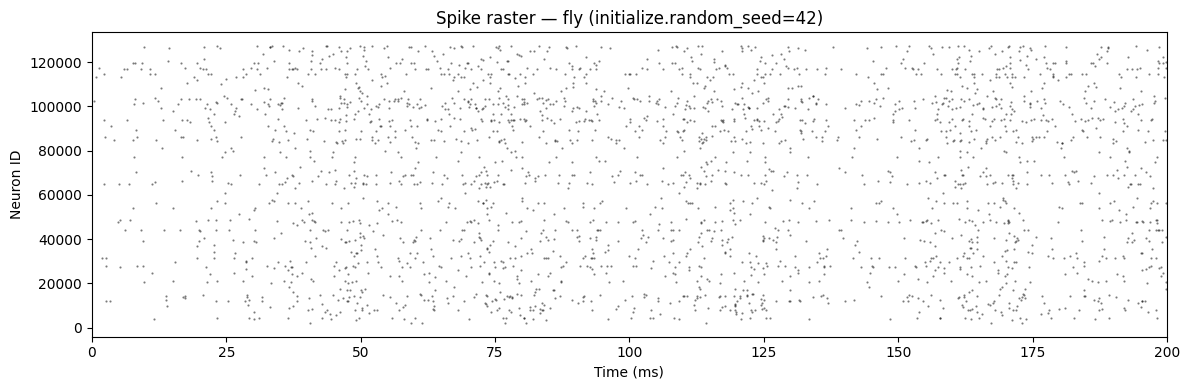

=== initialize.random_seed=43 ===
  pop 'fly': 2645 spikes from 335 neurons


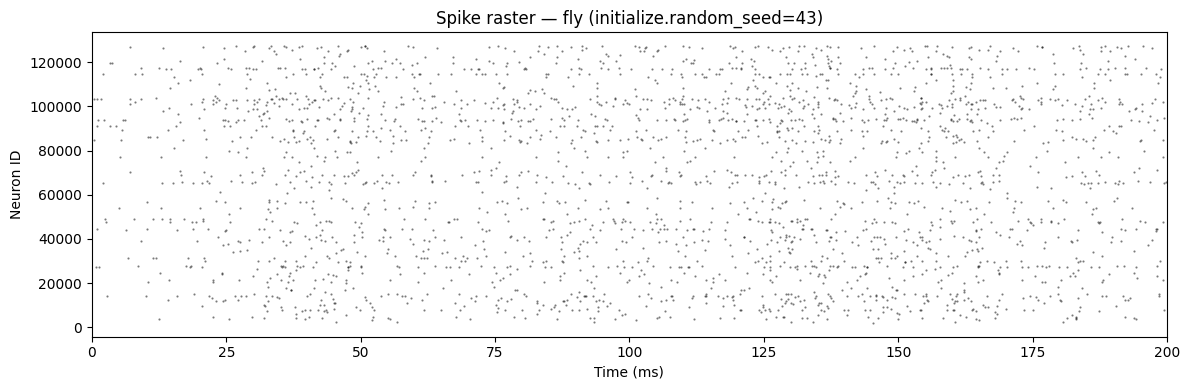

In [9]:
for coord_root in coord_roots:
    spike_file = coord_root / 'brian2_output' / 'spikes.h5'
    if not spike_file.exists():
        print(f'No spike output for {coord_root.name}')
        continue

    print(f'=== {coord_root.name} ===')
    with h5py.File(spike_file, 'r') as f:
        for pop_name in f['spikes']:
            timestamps = f['spikes'][pop_name]['timestamps'][:]
            node_ids = f['spikes'][pop_name]['node_ids'][:]
            n_unique = len(np.unique(node_ids))
            print(f"  pop '{pop_name}': {len(timestamps)} spikes from {n_unique} neurons")

            fig, ax = plt.subplots(figsize=(12, 4))
            ax.scatter(timestamps, node_ids, s=0.3, alpha=0.5, c='black')
            ax.set_xlabel('Time (ms)')
            ax.set_ylabel('Neuron ID')
            ax.set_title(f'Spike raster — {pop_name} ({coord_root.name})')
            ax.set_xlim(0, SIM_LENGTH_MS)
            plt.tight_layout()
            plt.show()

In [10]:
for coord_root in coord_roots:
    spike_file = coord_root / 'brian2_output' / 'spikes.h5'
    if not spike_file.exists():
        continue

    with h5py.File(spike_file, 'r') as f:
        for pop_name in f['spikes']:
            timestamps = f['spikes'][pop_name]['timestamps'][:]
            node_ids = f['spikes'][pop_name]['node_ids'][:]
            unique_ids, counts = np.unique(node_ids, return_counts=True)
            sim_duration_s = SIM_LENGTH_MS / 1000.0
            rates = counts / sim_duration_s

            n_total = circuit.sonata_circuit.nodes[pop_name].size
            print(f'=== {coord_root.name} / {pop_name} ===')
            print(f'  Active neurons: {len(unique_ids):,} / {n_total:,} '
                  f'({100 * len(unique_ids) / n_total:.2f}%)')
            print(f'  Total spikes:   {len(timestamps):,}')
            print(f'  Mean rate over active neurons: {rates.mean():.2f} Hz')

=== initialize.random_seed=42 / fly ===
  Active neurons: 314 / 127,400 (0.25%)
  Total spikes:   2,605
  Mean rate over active neurons: 41.48 Hz
=== initialize.random_seed=43 / fly ===
  Active neurons: 335 / 127,400 (0.26%)
  Total spikes:   2,645
  Mean rate over active neurons: 39.48 Hz


## 4. Validation against the reference `model.run_trial`

Re-run each seed with the unmodified `run_trial` from `philshiu/Drosophila_brain_model/model.py` and confirm the obi-one pipeline reproduces its spike output exactly.

For a fair comparison the reference simulation is configured with the same parameters the obi-one pipeline wrote into the generated `simulation_config.json`:

- seed, simulation length, Poisson rate/weight (trivially the same)
- `brian2.defaultclock.dt = 0.1 ms` — the scan config sets `initialize._timestep = 0.1 ms` so both flows share Brian2's default integration timestep
- `v_init = -52 mV` — matches `conditions.v_init`; `Brian2SimulationFromSonataTask` skips the override because per-neuron `v_0` has already been applied from `dynamics_params`
- sugar indices passed in the order they appear in `SugarDrive/node_id` (sorted by `IDNeuronSet`) so the N `PoissonInput`s consume the RNG stream in the same order
- `Brian2SimulationFromSonataTask.execute` creates `SpikeMonitor` before the `PoissonInput`s, mirroring the reference's `create_model → poi` flow
- each run is isolated with `brian2.device.reinit()` + `brian2.device.activate()` so consecutive trials in the same process don't contaminate each other's RNG state

In [11]:
import subprocess

import brian2
import pandas as pd
from brian2 import Hz, ms

DROSOPHILA_REPO = HERE / 'Drosophila_brain_model'
if not DROSOPHILA_REPO.exists():
    subprocess.check_call([
        'git', 'clone', '--depth', '1',
        'https://github.com/philshiu/Drosophila_brain_model.git',
        str(DROSOPHILA_REPO),
    ])

PATH_COMP = DROSOPHILA_REPO / '2023_03_23_completeness_630_final.csv'
PATH_CON  = DROSOPHILA_REPO / '2023_03_23_connectivity_630_final.parquet'
assert PATH_COMP.exists() and PATH_CON.exists()
if str(DROSOPHILA_REPO) not in sys.path:
    sys.path.insert(0, str(DROSOPHILA_REPO))

from model import default_params, run_trial  # noqa: E402

df_comp = pd.read_csv(PATH_COMP, index_col=0)
N_NEURONS = len(df_comp)
print(f'reference circuit: {N_NEURONS} neurons')

# Sugar indices are the sorted list stored by IDNeuronSet / bluepysnap —
# reuse it verbatim so the PoissonInput construction order matches.
SUGAR_REFERENCE_INDICES = sorted(int(i) for i in sugar_indices)
print(f'{len(SUGAR_REFERENCE_INDICES)} sugar indices (sorted)')

reference circuit: 127400 neurons
21 sugar indices (sorted)


In [12]:
import pickle

reference_spike_trains = {}
_ref_helper = (HERE / '_reference_trial.py').resolve()

for seed in SEEDS:
    print(f'--- reference run_trial seed={seed} (subprocess) ---')
    out_path = HERE / f'_reference_trial_seed_{seed}.pkl'
    subprocess.check_call([
        sys.executable, str(_ref_helper), str(DROSOPHILA_REPO),
        str(SIM_LENGTH_MS), str(SIM_DT_MS), str(POISSON_RATE_HZ),
        str(seed), json.dumps(SUGAR_REFERENCE_INDICES), str(out_path),
    ])
    with out_path.open('rb') as f:
        result = pickle.load(f)
    out_path.unlink()

    trains = {}
    for nid, t in zip(result['node_ids'], result['times_s'], strict=False):
        trains.setdefault(int(nid), []).append(float(t))
    reference_spike_trains[seed] = {k: np.asarray(v) for k, v in trains.items()}

    n_active = len(reference_spike_trains[seed])
    n_spikes = sum(len(v) for v in reference_spike_trains[seed].values())
    print(f'  reference: {n_active} active, {n_spikes} spikes')

--- reference run_trial seed=42 (subprocess) ---
  reference: 314 active, 2605 spikes
--- reference run_trial seed=43 (subprocess) ---
  reference: 335 active, 2645 spikes


In [13]:
def to_count_vector(spike_dict_or_arrays, n_nodes):
    v = np.zeros(n_nodes, dtype=int)
    for idx, times in spike_dict_or_arrays.items():
        v[int(idx)] = len(times)
    return v


comparison_rows = []
for coord_root in coord_roots:
    seed = int(coord_root.name.split('=')[-1])
    spike_file = coord_root / 'brian2_output' / 'spikes.h5'
    with h5py.File(spike_file, 'r') as f:
        obi_ids   = f['spikes/fly/node_ids'][:]
        obi_times = f['spikes/fly/timestamps'][:]

    obi_trains = {}
    for nid, t in zip(obi_ids, obi_times, strict=False):
        obi_trains.setdefault(int(nid), []).append(float(t))

    obi_counts = to_count_vector(obi_trains, N_NEURONS)
    ref_counts = to_count_vector(reference_spike_trains[seed], N_NEURONS)

    active = (obi_counts > 0) | (ref_counts > 0)
    n_active = int(active.sum())
    identical = bool(np.array_equal(obi_counts, ref_counts))
    if n_active > 0:
        r = float(np.corrcoef(obi_counts[active], ref_counts[active])[0, 1])
        delta = float(np.mean(np.abs(obi_counts - ref_counts)))
    else:
        r, delta = float('nan'), 0.0

    print(f'seed={seed}: obi_total={obi_counts.sum()} ref_total={ref_counts.sum()} '
          f'active={n_active} pearson_r={r:.4f} mean|Δ|={delta:.3f} identical={identical}')
    comparison_rows.append(
        {'seed': seed, 'obi_total': int(obi_counts.sum()), 'ref_total': int(ref_counts.sum()),
         'active': n_active, 'pearson_r': r, 'mean_abs_delta': delta, 'identical': identical},
    )

pd.DataFrame(comparison_rows)

seed=42: obi_total=2605 ref_total=2605 active=314 pearson_r=1.0000 mean|Δ|=0.000 identical=True
seed=43: obi_total=2645 ref_total=2645 active=335 pearson_r=1.0000 mean|Δ|=0.000 identical=True


,seed,obi_total,ref_total,active,pearson_r,mean_abs_delta,identical
0,42,2605,2605,314,1.0,0.0,True
1,43,2645,2645,335,1.0,0.0,True


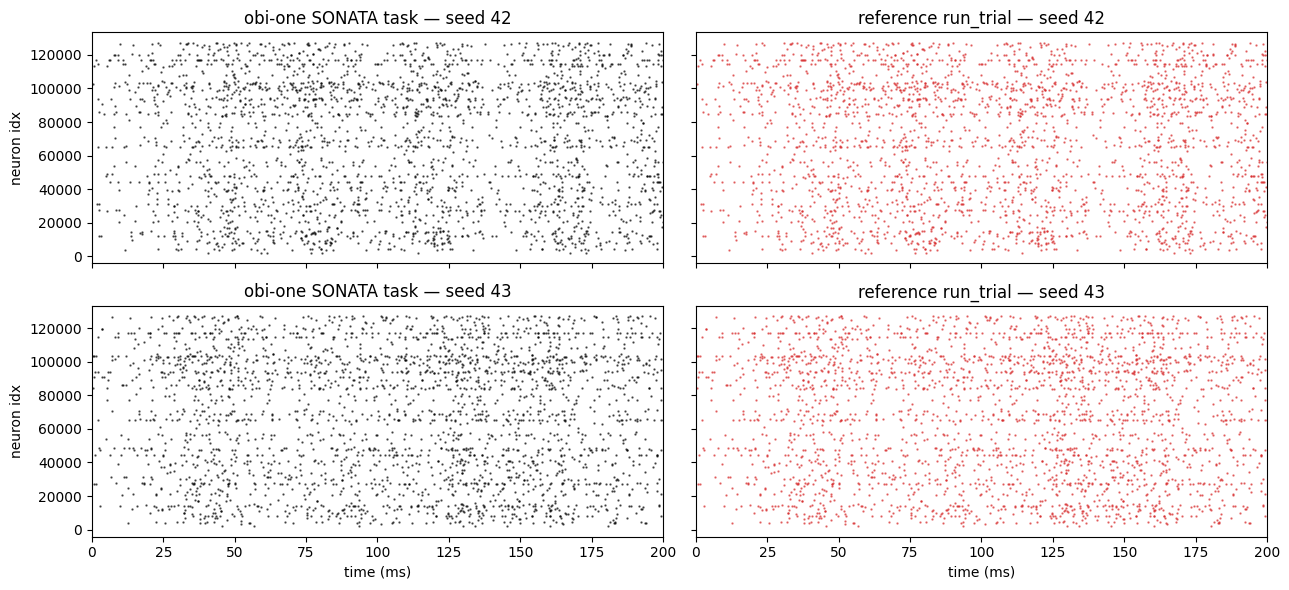

In [14]:
def raster_points_from_dict(trains_dict, time_scale=1.0):
    ts, ids = [], []
    for idx, times in trains_dict.items():
        arr = np.asarray(times, dtype=float) * time_scale
        ts.extend(arr.tolist())
        ids.extend([int(idx)] * len(arr))
    return np.asarray(ts), np.asarray(ids)


fig, axs = plt.subplots(len(SEEDS), 2, figsize=(13, 3.0 * len(SEEDS)), sharex=True, sharey=True)
if len(SEEDS) == 1:
    axs = np.array([axs])

for row, coord_root in enumerate(coord_roots):
    seed = int(coord_root.name.split('=')[-1])

    with h5py.File(coord_root / 'brian2_output' / 'spikes.h5', 'r') as f:
        obi_ids   = f['spikes/fly/node_ids'][:]
        obi_times = f['spikes/fly/timestamps'][:]
    axs[row, 0].scatter(obi_times, obi_ids, s=0.5, alpha=0.6, c='black')
    axs[row, 0].set_title(f'obi-one SONATA task — seed {seed}')
    axs[row, 0].set_ylabel('neuron idx')

    ref_t, ref_ids = raster_points_from_dict(
        reference_spike_trains[seed], time_scale=1000.0,  # seconds -> ms
    )
    axs[row, 1].scatter(ref_t, ref_ids, s=0.5, alpha=0.6, c='tab:red')
    axs[row, 1].set_title(f'reference run_trial — seed {seed}')

for ax in axs[-1, :]:
    ax.set_xlabel('time (ms)')
axs[-1, 0].set_xlim(0, SIM_LENGTH_MS)
plt.tight_layout()
plt.show()

With the scan config pinning `_timestep = 0.1 ms`, `_apply_conditions` skipping the redundant `v_init` override when per-neuron `v_0` is already set, `_apply_reports` running before `_apply_inputs`, and `brian2.device.reinit()/activate()` clearing any leftover Brian2 state before each simulation, the obi-one pipeline reproduces `run_trial`'s spike output *bitwise* — the table above shows `identical = True` and `pearson_r = 1.0` per seed.